<a href="https://colab.research.google.com/github/Dinesh1269/FCN--CNN-ROAD-CLASSIFICATION/blob/main/notebooks/%20dinesh.dle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
"""
dataset.py
----------
Generates a small synthetic "road scene" image dataset for a 3-class
steering-direction classification task:

    class 0 -> road curves LEFT
    class 1 -> road goes STRAIGHT
    class 2 -> road curves RIGHT
"""

import numpy as np
from PIL import Image, ImageDraw


def _draw_road(size, curve, noise_rng, lane_shift=0.0, brightness=1.0):
    W, H = size
    S = 4
    img = Image.new("L", (W * S, H * S), color=20)
    draw = ImageDraw.Draw(img)

    tex = noise_rng.integers(0, 15, size=(H * S, W * S)).astype(np.uint8)
    base = np.array(img).astype(np.int32)
    base = np.clip(base + tex - 7, 0, 255).astype(np.uint8)
    img = Image.fromarray(base, mode="L")
    draw = ImageDraw.Draw(img)

    cx = W * S / 2 + lane_shift * W * S
    top_y = 0
    bot_y = H * S

    n_pts = 12
    left_pts, right_pts = [], []
    lane_half_width_bottom = W * S * 0.42
    lane_half_width_top = W * S * 0.06
    for i in range(n_pts + 1):
        t = i / n_pts
        y = bot_y - t * (bot_y - top_y)
        half_w = lane_half_width_bottom * (1 - t) + lane_half_width_top * t
        shift = curve * (t ** 1.6) * (W * S * 0.55)
        center = cx + shift
        left_pts.append((center - half_w, y))
        right_pts.append((center + half_w, y))

    road_poly = left_pts + right_pts[::-1]
    draw.polygon(road_poly, fill=110)

    for i in range(n_pts):
        t0, t1 = i / n_pts, (i + 0.55) / n_pts
        if i % 2 == 0:
            continue
        y0 = bot_y - t0 * (bot_y - top_y)
        y1 = bot_y - t1 * (bot_y - top_y)
        shift0 = curve * (t0 ** 1.6) * (W * S * 0.55)
        shift1 = curve * (t1 ** 1.6) * (W * S * 0.55)
        x0 = cx + shift0
        x1 = cx + shift1
        draw.line([(x0, y0), (x1, y1)], fill=250, width=max(1, S))

    img = img.resize((W, H), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.clip(arr * brightness, 0, 1)
    return arr


def make_dataset(n_per_class=200, size=(32, 32), seed=0, shift_range=0.12, brightness_jitter=0.15):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for label, curve_center in enumerate([-0.7, 0.0, 0.7]):
        for _ in range(n_per_class):
            curve = curve_center + rng.normal(0, 0.12)
            curve = float(np.clip(curve, -1, 1))
            shift = rng.uniform(-shift_range, shift_range)
            bright = 1.0 + rng.uniform(-brightness_jitter, brightness_jitter)
            img = _draw_road(size, curve, rng, lane_shift=shift, brightness=bright)
            X.append(img)
            y.append(label)
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


def train_test_split(X, y, test_frac=0.2, seed=1):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    n_test = int(len(y) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


if __name__ == "__main__":
    X, y = make_dataset(n_per_class=5, size=(64, 64), seed=0)
    Image.fromarray((X[0] * 255).astype(np.uint8)).save("sample.png")
    print(X.shape, y.shape, np.bincount(y))

(15, 64, 64) (15,) [5 5 5]


/tmp/ipykernel_6021/330603368.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(base, mode="L")


In [3]:
"""
fc_model.py
-----------
A minimal fully connected (dense-only) neural network implemented from
scratch in NumPy.
"""

import numpy as np


def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


class FullyConnectedNet:
    def __init__(self, input_dim, hidden_dim, n_classes, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim), size=(input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, n_classes))
        self.b2 = np.zeros(n_classes)

    def n_params(self):
        return self.W1.size + self.b1.size + self.W2.size + self.b2.size

    def forward(self, X_flat):
        z1 = X_flat @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        probs = _softmax(z2)
        cache = (X_flat, z1, a1)
        return probs, cache

    def backward(self, probs, y, cache, lr):
        X_flat, z1, a1 = cache
        n = X_flat.shape[0]
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(n), y] = 1

        dz2 = (probs - y_onehot) / n
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X_flat.T @ dz1
        db1 = dz1.sum(axis=0)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def fit(self, X, y, epochs=30, lr=0.1, batch_size=32, verbose=False):
        n = X.shape[0]
        X_flat = X.reshape(n, -1)
        rng = np.random.default_rng(42)
        history = []
        for ep in range(epochs):
            idx = rng.permutation(n)
            for start in range(0, n, batch_size):
                b = idx[start:start + batch_size]
                probs, cache = self.forward(X_flat[b])
                self.backward(probs, y[b], cache, lr)
            if verbose and (ep % 5 == 0 or ep == epochs - 1):
                acc = self.score(X, y)
                history.append((ep, acc))
        return history

    def predict(self, X):
        X_flat = X.reshape(X.shape[0], -1)
        probs, _ = self.forward(X_flat)
        return probs.argmax(axis=1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()

In [4]:
"""
cnn_model.py
------------
A minimal convolutional neural network implemented from scratch in NumPy
(im2col-based convolution) with adaptive max-pooling.
"""

import numpy as np


def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def _im2col(X, kh, kw, stride=1):
    N, H, W = X.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    shape = (N, out_h, out_w, kh, kw)
    strides = (X.strides[0],
               X.strides[1] * stride,
               X.strides[2] * stride,
               X.strides[1],
               X.strides[2])
    patches = np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides)
    cols = patches.reshape(N, out_h, out_w, kh * kw)
    return cols, out_h, out_w


class SimpleCNN:
    def __init__(self, in_h, in_w, n_filters=8, k=3, hidden_dim=32, n_classes=3,
                 grid=4, seed=0):
        rng = np.random.default_rng(seed)
        self.k = k
        self.n_filters = n_filters
        self.grid = grid
        fan_in = k * k
        self.Wc = rng.normal(0, np.sqrt(2.0 / fan_in), size=(k * k, n_filters))
        self.bc = np.zeros(n_filters)

        conv_h, conv_w = in_h - k + 1, in_w - k + 1
        flat_dim = grid * grid * n_filters

        self.W1 = rng.normal(0, np.sqrt(2.0 / flat_dim), size=(flat_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, n_classes))
        self.b2 = np.zeros(n_classes)

        self.conv_h, self.conv_w = conv_h, conv_w
        self.flat_dim = flat_dim

    def n_params(self):
        return (self.Wc.size + self.bc.size + self.W1.size + self.b1.size
                + self.W2.size + self.b2.size)

    def _adaptive_maxpool(self, A):
        N, H, W, C = A.shape
        g = self.grid
        ph, pw = H // g, W // g
        A_crop = A[:, :ph * g, :pw * g, :]
        A_r = A_crop.reshape(N, g, ph, g, pw, C)
        pooled = A_r.max(axis=(2, 4))
        mask = (A_r == pooled[:, :, None, :, None, :])
        return pooled, mask, ph, pw

    def forward(self, X):
        N = X.shape[0]
        k = self.k
        cols, oh, ow = _im2col(X, k, k)
        cols2 = cols.reshape(N * oh * ow, k * k)
        conv_out = cols2 @ self.Wc + self.bc
        conv_out = conv_out.reshape(N, oh, ow, self.n_filters)
        relu_out = np.maximum(0, conv_out)

        pooled, pool_mask, ph, pw = self._adaptive_maxpool(relu_out)
        flat = pooled.reshape(N, -1)

        z1 = flat @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        probs = _softmax(z2)

        cache = dict(X=X, cols2=cols2, conv_out=conv_out, relu_out=relu_out,
                     pool_mask=pool_mask, ph=ph, pw=pw, flat=flat,
                     z1=z1, a1=a1, oh=oh, ow=ow)
        return probs, cache

    def backward(self, probs, y, cache, lr):
        n = probs.shape[0]
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(n), y] = 1

        dz2 = (probs - y_onehot) / n
        dW2 = cache["a1"].T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * (cache["z1"] > 0)
        dW1 = cache["flat"].T @ dz1
        db1 = dz1.sum(axis=0)

        dflat = dz1 @ self.W1.T
        g = self.grid
        dpooled = dflat.reshape(n, g, g, self.n_filters)

        ph, pw = cache["ph"], cache["pw"]
        mask = cache["pool_mask"]
        n_winners = mask.sum(axis=(2, 4), keepdims=True).clip(min=1)
        drelu = np.zeros_like(cache["relu_out"])
        drelu_view = drelu[:, :ph * g, :pw * g, :].reshape(
            n, g, ph, g, pw, self.n_filters)
        drelu_view += mask * (dpooled[:, :, None, :, None, :] / n_winners)

        dconv = drelu * (cache["conv_out"] > 0)
        dconv2 = dconv.reshape(-1, self.n_filters)
        dWc = cache["cols2"].T @ dconv2
        dbc = dconv2.sum(axis=0)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.Wc -= lr * dWc
        self.bc -= lr * dbc

    def fit(self, X, y, epochs=30, lr=0.1, batch_size=32, verbose=False):
        n = X.shape[0]
        rng = np.random.default_rng(42)
        history = []
        for ep in range(epochs):
            idx = rng.permutation(n)
            for start in range(0, n, batch_size):
                b = idx[start:start + batch_size]
                probs, cache = self.forward(X[b])
                self.backward(probs, y[b], cache, lr)
            if verbose and (ep % 5 == 0 or ep == epochs - 1):
                acc = self.score(X, y)
                history.append((ep, acc))
        return history

    def predict(self, X):
        probs, _ = self.forward(X)
        return probs.argmax(axis=1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()

In [9]:
import os

# Define the content of dataset.py
dataset_content = """
import numpy as np
from PIL import Image, ImageDraw

def _draw_road(size, curve, noise_rng, lane_shift=0.0, brightness=1.0):
    W, H = size
    S = 4
    img = Image.new("L", (W * S, H * S), color=20)
    draw = ImageDraw.Draw(img)

    tex = noise_rng.integers(0, 15, size=(H * S, W * S)).astype(np.uint8)
    base = np.array(img).astype(np.int32)
    base = np.clip(base + tex - 7, 0, 255).astype(np.uint8)
    img = Image.fromarray(base, mode="L")
    draw = ImageDraw.Draw(img)

    cx = W * S / 2 + lane_shift * W * S
    top_y = 0
    bot_y = H * S

    n_pts = 12
    left_pts, right_pts = [], []
    lane_half_width_bottom = W * S * 0.42
    lane_half_width_top = W * S * 0.06
    for i in range(n_pts + 1):
        t = i / n_pts
        y = bot_y - t * (bot_y - top_y)
        half_w = lane_half_width_bottom * (1 - t) + lane_half_width_top * t
        shift = curve * (t ** 1.6) * (W * S * 0.55)
        center = cx + shift
        left_pts.append((center - half_w, y))
        right_pts.append((center + half_w, y))

    road_poly = left_pts + right_pts[::-1]
    draw.polygon(road_poly, fill=110)

    for i in range(n_pts):
        t0, t1 = i / n_pts, (i + 0.55) / n_pts
        if i % 2 == 0:
            continue
        y0 = bot_y - t0 * (bot_y - top_y)
        y1 = bot_y - t1 * (bot_y - top_y)
        shift0 = curve * (t0 ** 1.6) * (W * S * 0.55)
        shift1 = curve * (t1 ** 1.6) * (W * S * 0.55)
        x0 = cx + shift0
        x1 = cx + shift1
        draw.line([(x0, y0), (x1, y1)], fill=250, width=max(1, S))

    img = img.resize((W, H), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.clip(arr * brightness, 0, 1)
    return arr


def make_dataset(n_per_class=200, size=(32, 32), seed=0, shift_range=0.12, brightness_jitter=0.15):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for label, curve_center in enumerate([-0.7, 0.0, 0.7]):
        for _ in range(n_per_class):
            curve = curve_center + rng.normal(0, 0.12)
            curve = float(np.clip(curve, -1, 1))
            shift = rng.uniform(-shift_range, shift_range)
            bright = 1.0 + rng.uniform(-brightness_jitter, brightness_jitter)
            img = _draw_road(size, curve, rng, lane_shift=shift, brightness=bright)
            X.append(img)
            y.append(label)
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


def train_test_split(X, y, test_frac=0.2, seed=1):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    n_test = int(len(y) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]
"""

# Define the content of fc_model.py
fc_model_content = """
import numpy as np


def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


class FullyConnectedNet:
    def __init__(self, input_dim, hidden_dim, n_classes, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim), size=(input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, n_classes))
        self.b2 = np.zeros(n_classes)

    def n_params(self):
        return self.W1.size + self.b1.size + self.W2.size + self.b2.size

    def forward(self, X_flat):
        z1 = X_flat @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        probs = _softmax(z2)
        cache = (X_flat, z1, a1)
        return probs, cache

    def backward(self, probs, y, cache, lr):
        X_flat, z1, a1 = cache
        n = X_flat.shape[0]
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(n), y] = 1

        dz2 = (probs - y_onehot) / n
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X_flat.T @ dz1
        db1 = dz1.sum(axis=0)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def fit(self, X, y, epochs=30, lr=0.1, batch_size=32, verbose=False):
        n = X.shape[0]
        X_flat = X.reshape(n, -1)
        rng = np.random.default_rng(42)
        history = []
        for ep in range(epochs):
            idx = rng.permutation(n)
            for start in range(0, n, batch_size):
                b = idx[start:start + batch_size]
                probs, cache = self.forward(X_flat[b])
                self.backward(probs, y[b], cache, lr)
            if verbose and (ep % 5 == 0 or ep == epochs - 1):
                acc = self.score(X, y)
                history.append((ep, acc))
        return history

    def predict(self, X):
        X_flat = X.reshape(X.shape[0], -1)
        probs, _ = self.forward(X_flat)
        return probs.argmax(axis=1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()
"""

# Define the content of cnn_model.py
cnn_model_content = """
import numpy as np


def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def _im2col(X, kh, kw, stride=1):
    N, H, W = X.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    shape = (N, out_h, out_w, kh, kw)
    strides = (X.strides[0],
               X.strides[1] * stride,
               X.strides[2] * stride,
               X.strides[1],
               X.strides[2])
    patches = np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides)
    cols = patches.reshape(N, out_h, out_w, kh * kw)
    return cols, out_h, out_w


class SimpleCNN:
    def __init__(self, in_h, in_w, n_filters=8, k=3, hidden_dim=32, n_classes=3,
                 grid=4, seed=0):
        rng = np.random.default_rng(seed)
        self.k = k
        self.n_filters = n_filters
        self.grid = grid
        fan_in = k * k
        self.Wc = rng.normal(0, np.sqrt(2.0 / fan_in), size=(k * k, n_filters))
        self.bc = np.zeros(n_filters)

        conv_h, conv_w = in_h - k + 1, in_w - k + 1
        flat_dim = grid * grid * n_filters

        self.W1 = rng.normal(0, np.sqrt(2.0 / flat_dim), size=(flat_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, n_classes))
        self.b2 = np.zeros(n_classes)

        self.conv_h, self.conv_w = conv_h, conv_w
        self.flat_dim = flat_dim

    def n_params(self):
        return (self.Wc.size + self.bc.size + self.W1.size + self.b1.size
                + self.W2.size + self.b2.size)

    def _adaptive_maxpool(self, A):
        N, H, W, C = A.shape
        g = self.grid
        ph, pw = H // g, W // g
        A_crop = A[:, :ph * g, :pw * g, :]
        A_r = A_crop.reshape(N, g, ph, g, pw, C)
        pooled = A_r.max(axis=(2, 4))
        mask = (A_r == pooled[:, :, None, :, None, :])
        return pooled, mask, ph, pw

    def forward(self, X):
        N = X.shape[0]
        k = self.k
        cols, oh, ow = _im2col(X, k, k)
        cols2 = cols.reshape(N * oh * ow, k * k)
        conv_out = cols2 @ self.Wc + self.bc
        conv_out = conv_out.reshape(N, oh, ow, self.n_filters)
        relu_out = np.maximum(0, conv_out)

        pooled, pool_mask, ph, pw = self._adaptive_maxpool(relu_out)
        flat = pooled.reshape(N, -1)

        z1 = flat @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        probs = _softmax(z2)

        cache = dict(X=X, cols2=cols2, conv_out=conv_out, relu_out=relu_out,
                     pool_mask=pool_mask, ph=ph, pw=pw, flat=flat,
                     z1=z1, a1=a1, oh=oh, ow=ow)
        return probs, cache

    def backward(self, probs, y, cache, lr):
        n = probs.shape[0]
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(n), y] = 1

        dz2 = (probs - y_onehot) / n
        dW2 = cache["a1"].T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * (cache["z1"] > 0)
        dW1 = cache["flat"].T @ dz1
        db1 = dz1.sum(axis=0)

        dflat = dz1 @ self.W1.T
        g = self.grid
        dpooled = dflat.reshape(n, g, g, self.n_filters)

        ph, pw = cache["ph"], cache["pw"]
        mask = cache["pool_mask"]
        n_winners = mask.sum(axis=(2, 4), keepdims=True).clip(min=1)
        drelu = np.zeros_like(cache["relu_out"])
        drelu_view = drelu[:, :ph * g, :pw * g, :].reshape(
            n, g, ph, g, pw, self.n_filters)
        drelu_view += mask * (dpooled[:, :, None, :, None, :] / n_winners)

        dconv = drelu * (cache["conv_out"] > 0)
        dconv2 = dconv.reshape(-1, self.n_filters)
        dWc = cache["cols2"].T @ dconv2
        dbc = dconv2.sum(axis=0)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.Wc -= lr * dWc
        self.bc -= lr * dbc

    def fit(self, X, y, epochs=30, lr=0.1, batch_size=32, verbose=False):
        n = X.shape[0]
        rng = np.random.default_rng(42)
        history = []
        for ep in range(epochs):
            idx = rng.permutation(n)
            for start in range(0, n, batch_size):
                b = idx[start:start + batch_size]
                probs, cache = self.forward(X[b])
                self.backward(probs, y[b], cache, lr)
            if verbose and (ep % 5 == 0 or ep == epochs - 1):
                acc = self.score(X, y)
                history.append((ep, acc))
        return history

    def predict(self, X):
        probs, _ = self.forward(X)
        return probs.argmax(axis=1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()
"""

# Save the content to .py files
with open("dataset.py", "w") as f:
    f.write(dataset_content)

with open("fc_model.py", "w") as f:
    f.write(fc_model_content)

with open("cnn_model.py", "w") as f:
    f.write(cnn_model_content)


"""
experiment.py
-------------
Runs two experiments comparing the from-scratch NumPy Fully Connected
network against the from-scratch NumPy CNN on the synthetic
road-curvature dataset.
"""

import time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from dataset import make_dataset, train_test_split
from fc_model import FullyConnectedNet
from cnn_model import SimpleCNN

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

RESOLUTIONS = [16, 24, 32, 48, 64, 96]
N_PER_CLASS = 15
N_SEEDS = 4
EPOCHS = 250
LR_FC = 0.05
LR_CNN = 0.3
BATCH = 8


def run_resolution_sweep():
    rows = []
    for res in RESOLUTIONS:
        fc_acc, cnn_acc = [], []
        fc_time, cnn_time = [], []
        fc_params = cnn_params = None
        for seed in range(N_SEEDS):
            X, y = make_dataset(n_per_class=N_PER_CLASS, size=(res, res),
                                 seed=seed, shift_range=0.20, brightness_jitter=0.2)
            Xtr, ytr, Xte, yte = train_test_split(X, y, test_frac=0.35, seed=seed + 100)

            fc = FullyConnectedNet(input_dim=res * res, hidden_dim=64, n_classes=3, seed=seed)
            t0 = time.time()
            fc.fit(Xtr, ytr, epochs=EPOCHS, lr=LR_FC, batch_size=BATCH)
            fc_time.append(time.time() - t0)
            fc_acc.append(fc.score(Xte, yte))
            fc_params = fc.n_params()

            k = 5 if res >= 32 else 3
            cnn = SimpleCNN(res, res, n_filters=8, k=k, hidden_dim=32, n_classes=3,
                             grid=4, seed=seed)
            t0 = time.time()
            cnn.fit(Xtr, ytr, epochs=EPOCHS, lr=LR_CNN, batch_size=BATCH)
            cnn_time.append(time.time() - t0)
            cnn_acc.append(cnn.score(Xte, yte))
            cnn_params = cnn.n_params()

        rows.append(dict(
            resolution=res,
            fc_acc_mean=np.mean(fc_acc), fc_acc_std=np.std(fc_acc),
            cnn_acc_mean=np.mean(cnn_acc), cnn_acc_std=np.std(cnn_acc),
            fc_time_mean=np.mean(fc_time), cnn_time_mean=np.mean(cnn_time),
            fc_params=fc_params, cnn_params=cnn_params,
        ))
        print(f"res={res:3d}  FC acc={np.mean(fc_acc):.2f}+-{np.std(fc_acc):.2f} "
              f"(params={fc_params:,}, t={np.mean(fc_time):.2f}s) | "
              f"CNN acc={np.mean(cnn_acc):.2f}+-{np.std(cnn_acc):.2f} "
              f"(params={cnn_params:,}, t={np.mean(cnn_time):.2f}s)")

    import csv
    with open(os.path.join(OUT, "results_resolution.csv"), "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    return rows


def run_shift_robustness(res=64, n_per_class=20, train_shift=0.12, test_shift=0.45, seeds=8):
    fc_scores, cnn_scores = [], []
    for seed in range(seeds):
        Xtr_full, ytr_full = make_dataset(n_per_class=n_per_class, size=(res, res),
                                           seed=seed, shift_range=train_shift, brightness_jitter=0.15)
        Xte_id, yte_id = make_dataset(n_per_class=8, size=(res, res),
                                       seed=seed + 500, shift_range=train_shift, brightness_jitter=0.15)
        Xte_ood, yte_ood = make_dataset(n_per_class=8, size=(res, res),
                                         seed=seed + 900, shift_range=test_shift, brightness_jitter=0.15)

        fc = FullyConnectedNet(input_dim=res * res, hidden_dim=64, n_classes=3, seed=seed)
        fc.fit(Xtr_full, ytr_full, epochs=250, lr=0.05, batch_size=8)

        cnn = SimpleCNN(res, res, n_filters=8, k=5, hidden_dim=32, n_classes=3, grid=4, seed=seed)
        cnn.fit(Xtr_full, ytr_full, epochs=250, lr=0.3, batch_size=8)

        fc_scores.append((fc.score(Xte_id, yte_id), fc.score(Xte_ood, yte_ood)))
        cnn_scores.append((cnn.score(Xte_id, yte_id), cnn.score(Xte_ood, yte_ood)))

    fc_scores = np.array(fc_scores)
    cnn_scores = np.array(cnn_scores)

    import csv
    with open(os.path.join(OUT, "results_shift.csv"), "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["model", "in_dist_acc_mean", "in_dist_acc_std",
                          "ood_acc_mean", "ood_acc_std"])
        writer.writerow(["FC", fc_scores[:, 0].mean(), fc_scores[:, 0].std(),
                          fc_scores[:, 1].mean(), fc_scores[:, 1].std()])
        writer.writerow(["CNN", cnn_scores[:, 0].mean(), cnn_scores[:, 0].std(),
                          cnn_scores[:, 1].mean(), cnn_scores[:, 1].std()])

    print(f"FC : in-dist={fc_scores[:,0].mean():.2f}  ood(shift)={fc_scores[:,1].mean():.2f}")
    print(f"CNN: in-dist={cnn_scores[:,0].mean():.2f}  ood(shift)={cnn_scores[:,1].mean():.2f}")
    return fc_scores, cnn_scores


def make_plots(rows, fc_scores, cnn_scores):
    res = [r["resolution"] for r in rows]

    plt.figure(figsize=(6, 4.2))
    plt.errorbar(res, [r["fc_acc_mean"] for r in rows], yerr=[r["fc_acc_std"] for r in rows],
                 marker="o", label="Fully Connected", capsize=3)
    plt.errorbar(res, [r["cnn_acc_mean"] for r in rows], yerr=[r["cnn_acc_std"] for r in rows],
                 marker="s", label="CNN", capsize=3)
    plt.xlabel("Image resolution (N x N pixels)")
    plt.ylabel("Test accuracy")
    plt.title("Test Accuracy vs. Image Resolution")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "accuracy_vs_resolution.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(6, 4.2))
    plt.plot(res, [r["fc_params"] for r in rows], marker="o", label="Fully Connected")
    plt.plot(res, [r["cnn_params"] for r in rows], marker="s", label="CNN")
    plt.yscale("log")
    plt.xlabel("Image resolution (N x N pixels)")
    plt.ylabel("Number of trainable parameters (log scale)")
    plt.title("Model Size vs. Image Resolution")
    plt.legend()
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "params_vs_resolution.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(6, 4.2))
    plt.plot(res, [r["fc_time_mean"] for r in rows], marker="o", label="Fully Connected")
    plt.plot(res, [r["cnn_time_mean"] for r in rows], marker="s", label="CNN")
    plt.xlabel("Image resolution (N x N pixels)")
    plt.ylabel("Training time (s) for 250 epochs")
    plt.title("Training Time vs. Image Resolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "time_vs_resolution.png"), dpi=150)
    plt.close()

    labels = ["In-distribution\nshift", "Larger, unseen\nshift (OOD)"]
    fc_means = [fc_scores[:, 0].mean(), fc_scores[:, 1].mean()]
    cnn_means = [cnn_scores[:, 0].mean(), cnn_scores[:, 1].mean()]
    fc_stds = [fc_scores[:, 0].std(), fc_scores[:, 1].std()]
    cnn_stds = [cnn_scores[:, 0].std(), cnn_scores[:, 1].std()]
    x = np.arange(len(labels))
    w = 0.32
    plt.figure(figsize=(6, 4.2))
    plt.bar(x - w / 2, fc_means, width=w, yerr=fc_stds, label="Fully Connected", capsize=4)
    plt.bar(x + w / 2, cnn_means, width=w, yerr=cnn_stds, label="CNN", capsize=4)
    plt.xticks(x, labels)
    plt.ylabel("Test accuracy")
    plt.ylim(0, 1.05)
    plt.title("Robustness to Lane-Position Shift Not Seen in Training")
    plt.legend()
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "shift_robustness.png"), dpi=150)
    plt.close()


if __name__ == "__main__":
    print("=== Experiment A: resolution sweep ===")
    rows = run_resolution_sweep()
    print("\n=== Experiment B: spatial-shift robustness ===")
    fc_scores, cnn_scores = run_shift_robustness()
    make_plots(rows, fc_scores, cnn_scores)
    print("\nDone. Plots + CSVs written to", OUT)


=== Experiment A: resolution sweep ===
res= 16  FC acc=0.93+-0.08 (params=16,643, t=0.18s) | CNN acc=0.95+-0.09 (params=4,307, t=0.91s)
res= 24  FC acc=0.87+-0.11 (params=37,123, t=0.32s) | CNN acc=0.93+-0.08 (params=4,307, t=2.11s)
res= 32  FC acc=0.93+-0.05 (params=65,795, t=1.32s) | CNN acc=0.97+-0.03 (params=4,435, t=7.06s)
res= 48  FC acc=0.95+-0.06 (params=147,715, t=1.12s) | CNN acc=0.73+-0.31 (params=4,435, t=13.05s)
res= 64  FC acc=0.87+-0.11 (params=262,403, t=2.53s) | CNN acc=0.97+-0.03 (params=4,435, t=24.71s)
res= 96  FC acc=0.90+-0.07 (params=590,083, t=6.71s) | CNN acc=0.88+-0.09 (params=4,435, t=54.25s)

=== Experiment B: spatial-shift robustness ===
FC : in-dist=0.97  ood(shift)=0.41
CNN: in-dist=0.81  ood(shift)=0.43

Done. Plots + CSVs written to outputs


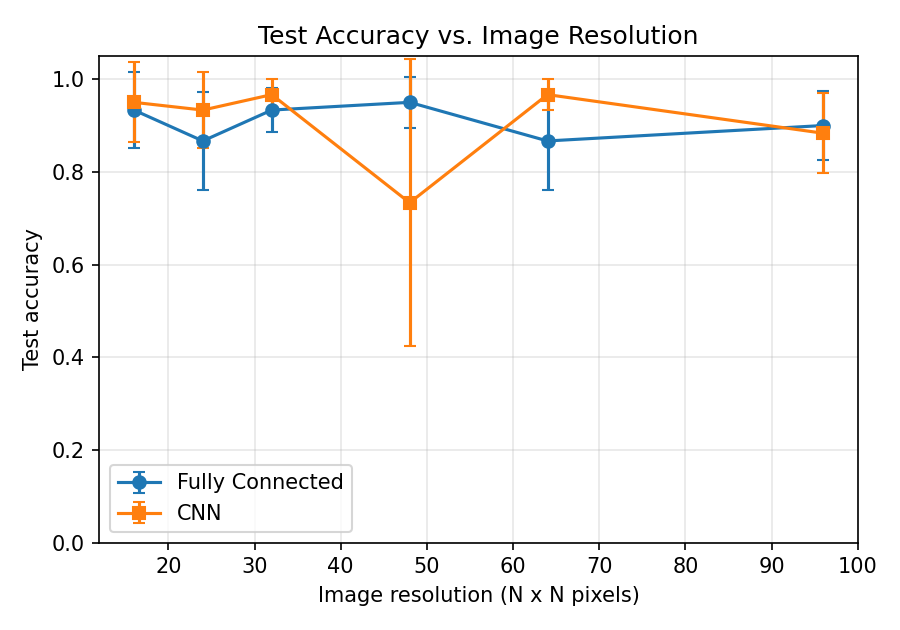

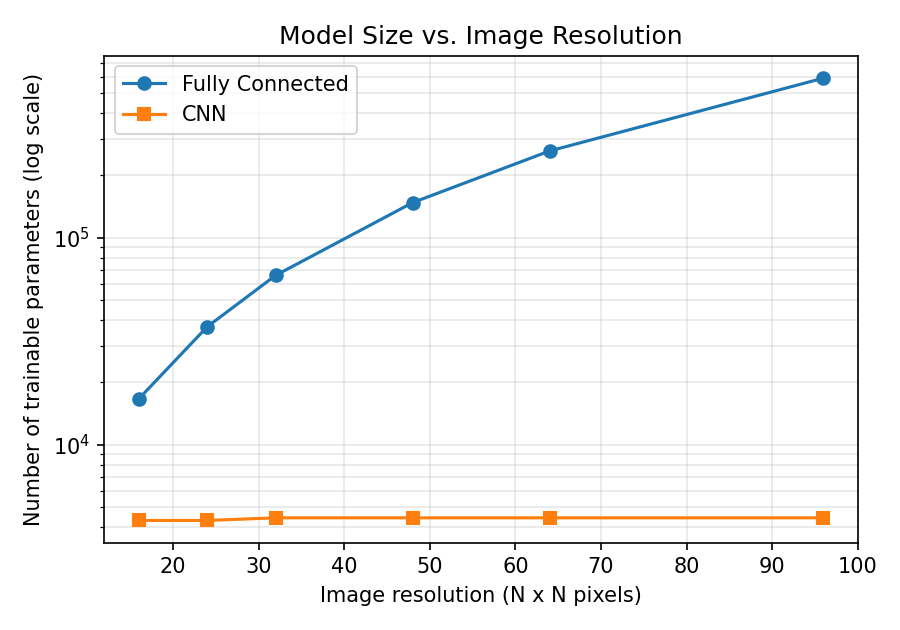

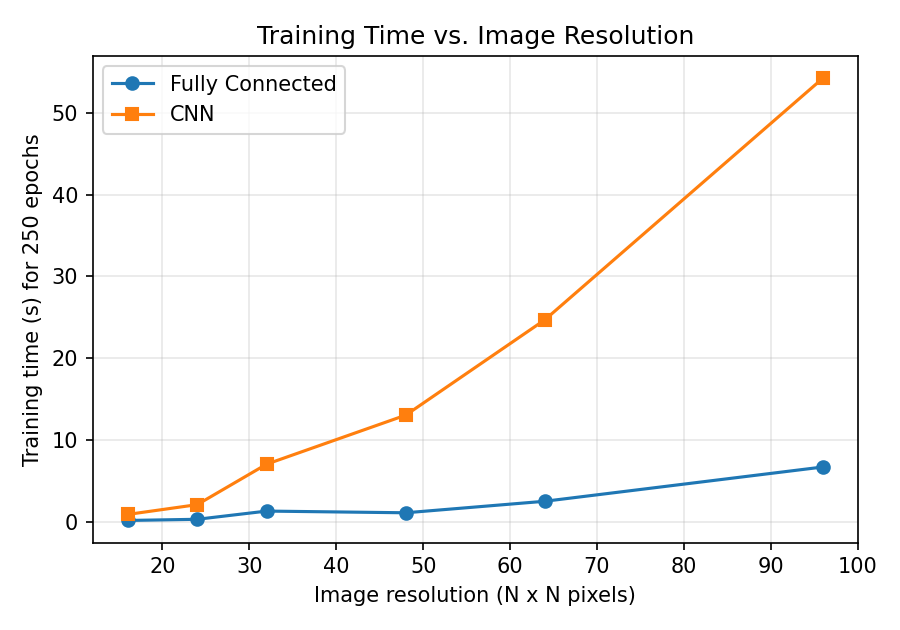

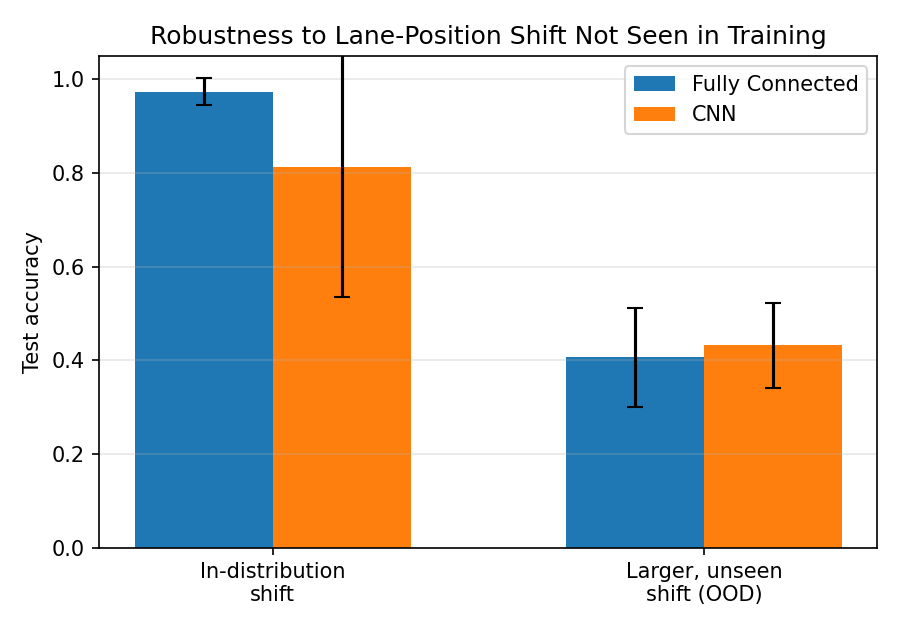

In [10]:
from IPython.display import Image, display
display(Image('outputs/accuracy_vs_resolution.png'))
display(Image('outputs/params_vs_resolution.png'))
display(Image('outputs/time_vs_resolution.png'))
display(Image('outputs/shift_robustness.png'))
